In [15]:
# -- cell 1: imports ---

import json
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from pathlib import Path
from torch.amp import autocast
import sys
sys.path.insert(0, '/home/vteam2/ayesha_xbd')

from dataset import get_dataloaders
from my_segformer import SegFormer

In [16]:
# --- cell 2 : config ---

PREPROCESSED_DIR = '/home/vteam2/ayesha_xbd/preprocessed'
CHECKPOINT_DIR   = Path('/home/vteam2/ayesha_xbd/checkpoints/segformer_run1')
HISTORY_PATH     = CHECKPOINT_DIR / 'training_history_segformer_run1.json'
CHECKPOINT_PATH  = CHECKPOINT_DIR / 'best_segformer_run1.pth'

NUM_CLASSES  = 4
BATCH_SIZE   = 8
DEVICE       = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
CLASS_NAMES  = ['no-damage', 'minor-damage', 'major-damage', 'destroyed']

print(f"Using device: {DEVICE}")

Using device: cuda


In [17]:
# --- cell 3: load best saved model for testing ---

print("Loading model...")
model = SegFormer(num_classes=NUM_CLASSES).to(DEVICE)

checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

print(f"Loaded checkpoint from epoch {checkpoint['epoch']} with val mIoU: {checkpoint['val_miou']:.4f}")

Loading model...


[transformers] You passed `num_labels=4` which is incompatible to the `id2label` map of length `1000`.
Loading weights: 100%|██████████| 364/364 [00:00<00:00, 29440.52it/s]
[transformers] SegformerForSemanticSegmentation LOAD REPORT from: nvidia/mit-b2
Key                                           | Status     | 
----------------------------------------------+------------+-
classifier.bias                               | UNEXPECTED | 
classifier.weight                             | UNEXPECTED | 
decode_head.batch_norm.running_mean           | MISSING    | 
decode_head.batch_norm.bias                   | MISSING    | 
decode_head.classifier.weight                 | MISSING    | 
decode_head.linear_c.{0, 1, 2, 3}.proj.bias   | MISSING    | 
decode_head.linear_fuse.weight                | MISSING    | 
decode_head.linear_c.{0, 1, 2, 3}.proj.weight | MISSING    | 
decode_head.batch_norm.num_batches_tracked    | MISSING    | 
decode_head.batch_norm.running_var            | MISSING    | 
dec

Loaded checkpoint from epoch 30 with val mIoU: 0.3213


In [18]:
# --- cell 4: metric functions ---

# same metrics as training: pixel acc, per class iou, miou, f1

def calculate_metrics(preds, masks, num_classes=NUM_CLASSES):

    preds = torch.argmax(preds, dim=1)
    preds = preds.cpu().numpy().flatten()
    masks = masks.cpu().numpy().flatten()

    pixel_acc     = (preds == masks).mean()
    iou_per_class = []
    f1_per_class  = []

    for c in range(num_classes):
        pred_c       = (preds == c)
        true_c       = (masks == c)
        intersection = (pred_c & true_c).sum()
        union        = (pred_c | true_c).sum()

        iou = intersection / (union + 1e-8)
        iou_per_class.append(iou)

        tp = intersection
        fp = (pred_c & ~true_c).sum()
        fn = (~pred_c & true_c).sum()
        f1 = (2 * tp) / (2 * tp + fp + fn + 1e-8)
        f1_per_class.append(f1)

    return {
        'pixel_acc':     pixel_acc,
        'miou':          np.mean(iou_per_class),
        'mf1':           np.mean(f1_per_class),
        'iou_per_class': iou_per_class,
        'f1_per_class':  f1_per_class
    }


# confusion matrix: rows = true, cols = predicted
def calculate_confusion_matrix(preds, masks, num_classes=NUM_CLASSES):

    preds = torch.argmax(preds, dim=1).cpu().numpy().flatten()
    masks = masks.cpu().numpy().flatten()

    cm = np.zeros((num_classes, num_classes), dtype=np.int64)
    for t, p in zip(masks, preds):
        cm[t][p] += 1

    return cm

In [19]:
# --- cell 5: test loop ---

# run inference on test set and aggregate metrics

def test(model, loader, device):
    model.eval()
    all_metrics   = {'pixel_acc': 0, 'miou': 0, 'mf1': 0}
    iou_per_class = np.zeros(NUM_CLASSES)
    f1_per_class  = np.zeros(NUM_CLASSES)
    confusion_mat = np.zeros((NUM_CLASSES, NUM_CLASSES), dtype=np.int64)

    with torch.no_grad():
        for pre, post, masks in loader:
            pre   = pre.to(device)
            post  = post.to(device)
            masks = masks.to(device)

            with autocast('cuda'):
                outputs = model(pre, post)

            metrics = calculate_metrics(outputs, masks)

            for k in all_metrics:
                all_metrics[k] += metrics[k]

            iou_per_class += np.array(metrics['iou_per_class'])
            f1_per_class += np.array(metrics['f1_per_class'])
            confusion_mat += calculate_confusion_matrix(outputs, masks)

    n = len(loader)
    avg_metrics = {k: v / n for k, v in all_metrics.items()}
    avg_metrics['iou_per_class'] = iou_per_class / n
    avg_metrics['f1_per_class'] = f1_per_class / n
    return avg_metrics, confusion_mat


# load test dataloader and run
print("Loading test data...")
_, _, test_loader = get_dataloaders(PREPROCESSED_DIR, batch_size=BATCH_SIZE)

print("Running inference on test set...")
test_metrics, confusion_mat = test(model, test_loader, DEVICE)


Loading test data...
Loaded train set: 3298 samples
Loaded val set: 856 samples
Loaded test set: 851 samples
Running inference on test set...


In [20]:
# --- cell 6:  print test results ---
print("=" * 50)
print("SegFormer Test Results")
print("=" * 50)
print(f"Pixel Accuracy: {test_metrics['pixel_acc']:.4f}")
print(f"mIoU:           {test_metrics['miou']:.4f}")
print(f"F1 Score:       {test_metrics['mf1']:.4f}")

print("\nPer-class IoU:")
for name, iou in zip(CLASS_NAMES, test_metrics['iou_per_class']):
    print(f"  {name}: {iou:.4f}")

print("\nPer-class F1:")
for name, f1 in zip(CLASS_NAMES, test_metrics['f1_per_class']):
    print(f"  {name}: {f1:.4f}")

SegFormer Test Results
Pixel Accuracy: 0.9720
mIoU:           0.3204
F1 Score:       0.3656

Per-class IoU:
  no-damage: 0.9731
  minor-damage: 0.0581
  major-damage: 0.1086
  destroyed: 0.1417

Per-class F1:
  no-damage: 0.9859
  minor-damage: 0.0953
  major-damage: 0.1647
  destroyed: 0.2165


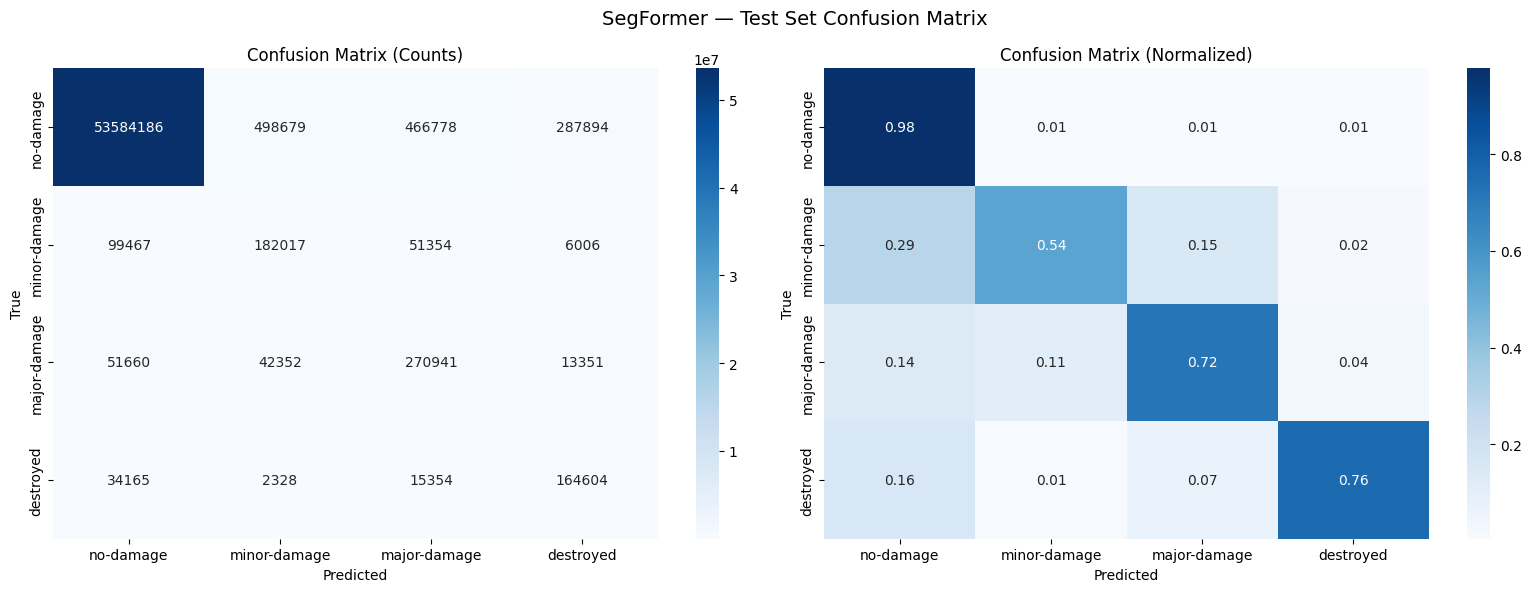

In [21]:
# --- cell 7: confusion matrix plot ---

# normalized confusion matrix heatmap
cm_normalized = confusion_mat.astype(float) / (confusion_mat.sum(axis=1, keepdims=True) + 1e-8)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# raw counts
sns.heatmap(confusion_mat, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[0])
axes[0].set_title('Confusion Matrix (Counts)')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')

# normalized
sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[1])
axes[1].set_title('Confusion Matrix (Normalized)')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')

plt.suptitle('SegFormer — Test Set Confusion Matrix', fontsize=14)
plt.tight_layout()
plt.savefig(CHECKPOINT_DIR / 'confusion_matrix_test.png', dpi=150, bbox_inches='tight')
plt.show()

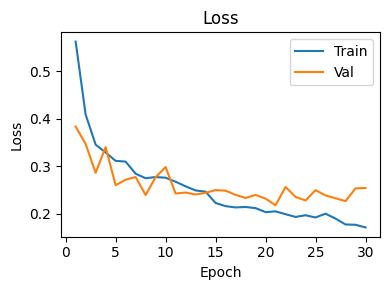

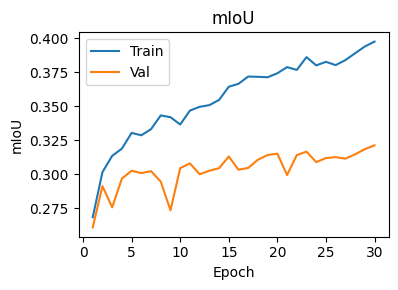

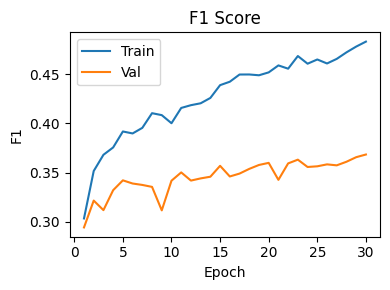

In [22]:
# --- cell 8: plot training curves ---
with open(HISTORY_PATH, 'r') as f:
    history = json.load(f)

epochs = range(1, len(history['train_loss']) + 1)

# loss plot
plt.figure(figsize=(4, 3))
plt.plot(epochs, history['train_loss'], label='Train')
plt.plot(epochs, history['val_loss'], label='Val')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.savefig(CHECKPOINT_DIR / 'loss.png', dpi=150, bbox_inches='tight')
plt.show()

# miou plot
plt.figure(figsize=(4, 3))
plt.plot(epochs, history['train_miou'], label='Train')
plt.plot(epochs, history['val_miou'], label='Val')
plt.title('mIoU')
plt.xlabel('Epoch')
plt.ylabel('mIoU')
plt.legend()
plt.tight_layout()
plt.savefig(CHECKPOINT_DIR / 'miou.png', dpi=150, bbox_inches='tight')
plt.show()

# f1 plot
plt.figure(figsize=(4, 3))
plt.plot(epochs, history['train_f1'], label='Train')
plt.plot(epochs, history['val_f1'], label='Val')
plt.title('F1 Score')
plt.xlabel('Epoch')
plt.ylabel('F1')
plt.legend()
plt.tight_layout()
plt.savefig(CHECKPOINT_DIR / 'f1.png', dpi=150, bbox_inches='tight')
plt.show()

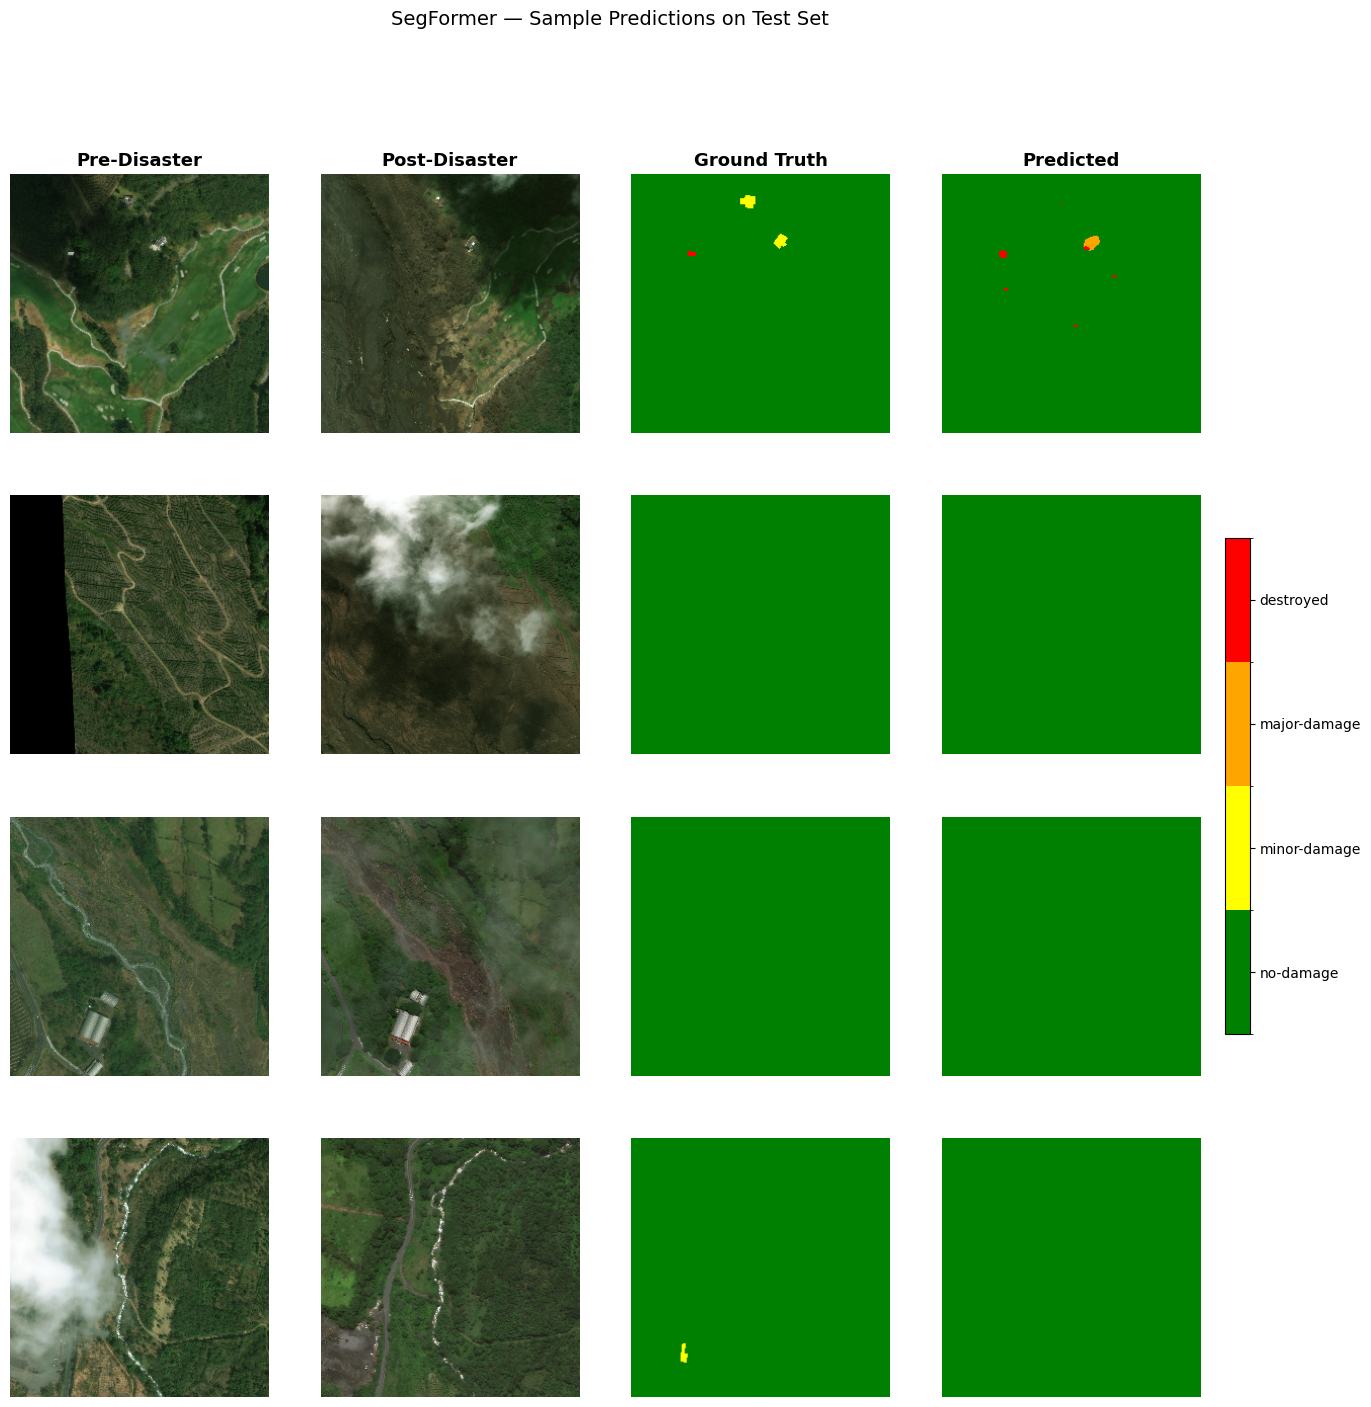

In [24]:
# --- cell 9: sample predictions --- 

# damage class colormap: matches preprocessing labels
# 0=no-damage, 1=minor, 2=major, 3=destroyed
CMAP   = mcolors.ListedColormap(['green', 'yellow', 'orange', 'red'])
BOUNDS = [0, 1, 2, 3, 4]
NORM   = mcolors.BoundaryNorm(BOUNDS, CMAP.N)

def visualize_predictions(model, loader, device, num_samples=4):

    model.eval()
    samples_shown = 0

    fig, axes = plt.subplots(num_samples, 4, figsize=(16, num_samples * 4))
    col_titles = ['Pre-Disaster', 'Post-Disaster', 'Ground Truth', 'Predicted']
    for ax, title in zip(axes[0], col_titles):
        ax.set_title(title, fontsize=13, fontweight='bold')

    with torch.no_grad():
        for pre, post, masks in loader:
            pre   = pre.to(device)
            post  = post.to(device)

            with autocast('cuda'):
                outputs = model(pre, post)

            preds = torch.argmax(outputs, dim=1).cpu().numpy()  # (batch, H, W)
            masks = masks.numpy()

            for i in range(pre.shape[0]):
                if samples_shown >= num_samples:
                    break

                # denormalize images back to [0, 255] for display
                pre_img  = pre[i].cpu().numpy().transpose(1, 2, 0)
                post_img = post[i].cpu().numpy().transpose(1, 2, 0)

                ax_row = axes[samples_shown]

                ax_row[0].imshow(pre_img)
                ax_row[0].axis('off')

                ax_row[1].imshow(post_img)
                ax_row[1].axis('off')

                ax_row[2].imshow(masks[i], cmap=CMAP, norm=NORM)
                ax_row[2].axis('off')

                ax_row[3].imshow(preds[i], cmap=CMAP, norm=NORM)
                ax_row[3].axis('off')

                samples_shown += 1

            if samples_shown >= num_samples:
                break

    # shared colorbar
    sm = plt.cm.ScalarMappable(cmap=CMAP, norm=NORM)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=axes, orientation='vertical', fraction=0.02, pad=0.02)
    cbar.set_ticks([0.5, 1.5, 2.5, 3.5])
    cbar.set_ticklabels(CLASS_NAMES)

    plt.suptitle('SegFormer — Sample Predictions on Test Set', fontsize=14)
    plt.savefig(CHECKPOINT_DIR / 'sample_predictions.png', dpi=150, bbox_inches='tight')
    plt.show()


visualize_predictions(model, test_loader, DEVICE, num_samples=4)